In [1]:
import gmsh
import numpy as np
import pyvista

from mpi4py import MPI
from dolfinx.io import gmshio
from dolfinx.plot import vtk_mesh
from matplotlib.colors import ListedColormap

# Parâmetros do problema
R  = 0.12e-3 / 2
d  = 6e-3
Ra = 2e-3
Rb = 9e-3

# Dimensões auxiliares da geometria
rho_max = Rb
z_max = 12e-3
z_nozzle = 3e-3
z_electrode = z_nozzle + d
t_electrode = 2 * R

# Parâmetros da malha
gdim = 2
model_rank = 0
mesh_comm = MPI.COMM_WORLD

# Tags dos subdomínios
AIR = 1
EMISSOR = 2
ELETRODO = 3

# Tamanhos característicos da malha
lc_far = 0.25e-3
lc_near = R / 4

In [2]:
# Inicializa o GMSH
if gmsh.isInitialized():
    gmsh.finalize()

gmsh.initialize()
gmsh.model.add("TC04_malha")

# Pontos do emissor
p0 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, lc_near)
p1 = gmsh.model.geo.addPoint(R,   0.0, 0.0, lc_near)
p2 = gmsh.model.geo.addPoint(R,   z_nozzle, 0.0, lc_near)
p3 = gmsh.model.geo.addPoint(0.0, z_nozzle + R, 0.0, lc_near)
pc = gmsh.model.geo.addPoint(0.0, z_nozzle, 0.0, lc_near)

# Pontos do domínio externo
p4 = gmsh.model.geo.addPoint(rho_max, 0.0, 0.0, lc_far)
p5 = gmsh.model.geo.addPoint(rho_max, z_max, 0.0, lc_far)
p6 = gmsh.model.geo.addPoint(0.0,     z_max, 0.0, lc_far)

# Pontos do eletrodo
p7  = gmsh.model.geo.addPoint(Ra,      z_electrode, 0.0, lc_far)
p8  = gmsh.model.geo.addPoint(rho_max, z_electrode, 0.0, lc_far)
p9  = gmsh.model.geo.addPoint(rho_max, z_electrode + t_electrode, 0.0, lc_far)
p10 = gmsh.model.geo.addPoint(Ra,      z_electrode + t_electrode, 0.0, lc_far)

In [3]:
# Linhas do emissor
l_em_bottom = gmsh.model.geo.addLine(p0, p1)
l_em_wall   = gmsh.model.geo.addLine(p1, p2)
l_em_arc    = gmsh.model.geo.addCircleArc(p2, pc, p3)
l_em_left   = gmsh.model.geo.addLine(p3, p0)

# Contorno fechado do emissor
emissor_loop = gmsh.model.geo.addCurveLoop([
    l_em_bottom,
    l_em_wall,
    l_em_arc,
    l_em_left
])

# Superfície do emissor
emissor_surface = gmsh.model.geo.addPlaneSurface([emissor_loop])

In [4]:
# Linhas do eletrodo
l_el_bottom = gmsh.model.geo.addLine(p7, p8)
l_el_right  = gmsh.model.geo.addLine(p8, p9)
l_el_top    = gmsh.model.geo.addLine(p9, p10)
l_el_left   = gmsh.model.geo.addLine(p10, p7)

# Contorno fechado do eletrodo
eletrodo_loop = gmsh.model.geo.addCurveLoop([
    l_el_bottom,
    l_el_right,
    l_el_top,
    l_el_left
])

# Superfície do eletrodo
eletrodo_surface = gmsh.model.geo.addPlaneSurface([eletrodo_loop])

In [5]:
# Linhas externas do domínio de ar
l_air_bottom = gmsh.model.geo.addLine(p1, p4)
l_air_right_low = gmsh.model.geo.addLine(p4, p8)
l_air_right_high = gmsh.model.geo.addLine(p9, p5)
l_air_top = gmsh.model.geo.addLine(p5, p6)
l_air_axis = gmsh.model.geo.addLine(p6, p3)

# Contorno do ar desviando do emissor e do eletrodo
air_loop = gmsh.model.geo.addCurveLoop([
    l_air_bottom,
    l_air_right_low,
    -l_el_bottom,
    -l_el_left,
    -l_el_top,
    l_air_right_high,
    l_air_top,
    l_air_axis,
    -l_em_arc,
    -l_em_wall
])

# Superfície do ar
air_surface = gmsh.model.geo.addPlaneSurface([air_loop])

# Sincroniza a geometria
gmsh.model.geo.synchronize()

In [6]:
# Grupo físico do ar
gmsh.model.addPhysicalGroup(2, [air_surface], AIR)
gmsh.model.setPhysicalName(2, AIR, "air")

# Grupo físico do emissor
gmsh.model.addPhysicalGroup(2, [emissor_surface], EMISSOR)
gmsh.model.setPhysicalName(2, EMISSOR, "emissor")

# Grupo físico do eletrodo
gmsh.model.addPhysicalGroup(2, [eletrodo_surface], ELETRODO)
gmsh.model.setPhysicalName(2, ELETRODO, "eletrodo")

# Define tamanho máximo dos elementos
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc_far)

# Gera a malha
gmsh.model.mesh.generate(gdim)

# Converte a malha do GMSH para DOLFINx
mesh, cell_tags, facet_tags = gmshio.model_to_mesh(
    gmsh.model,
    mesh_comm,
    model_rank,
    gdim=gdim
)

# Finaliza o GMSH
gmsh.finalize()

print("Tags nas células:", np.unique(cell_tags.values))

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Circle)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 70%] Meshing curve 10 (Line)
Info    : [ 80%] Meshing curve 11 (Line)
Info    : [ 90%] Meshing curve 12 (Line)
Info    : [100%] Meshing curve 13 (Line)
Info    : Done meshing 1D (Wall 0.0246746s, CPU 0.023053s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.475398s, CPU 0.4416s)
Info    : 12509 nodes 25290 elements
Tags nas células: [1 2 3]


In [7]:
# Prepara a malha para visualização
pyvista.start_xvfb()

mesh.topology.create_connectivity(gdim, gdim)

grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, gdim))

num_local_cells = mesh.topology.index_map(gdim).size_local
markers = np.zeros(num_local_cells, dtype=np.int32)

mask = cell_tags.indices < num_local_cells
markers[cell_tags.indices[mask]] = cell_tags.values[mask]

grid.cell_data["Marker"] = markers
grid.set_active_scalars("Marker")

# Mapa de cores: ar roxo, emissor vermelho, eletrodo amarelo
cmap_tags = ListedColormap([
    "#440154",
    "red",
    "yellow"
])

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


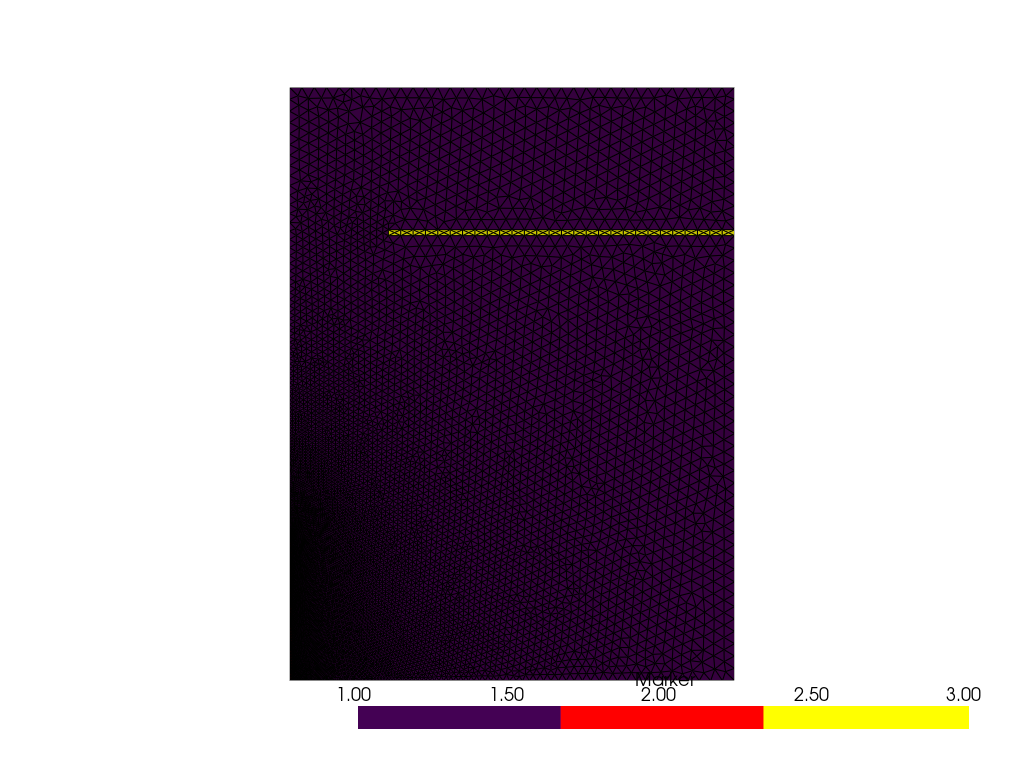

In [8]:
# Plot geral da malha
plotter = pyvista.Plotter()

plotter.add_mesh(
    grid,
    scalars="Marker",
    show_edges=True,
    cmap=cmap_tags,
    clim=[1, 3],
    edge_color="black",
    show_scalar_bar=True
)

plotter.view_xy()
plotter.show()

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


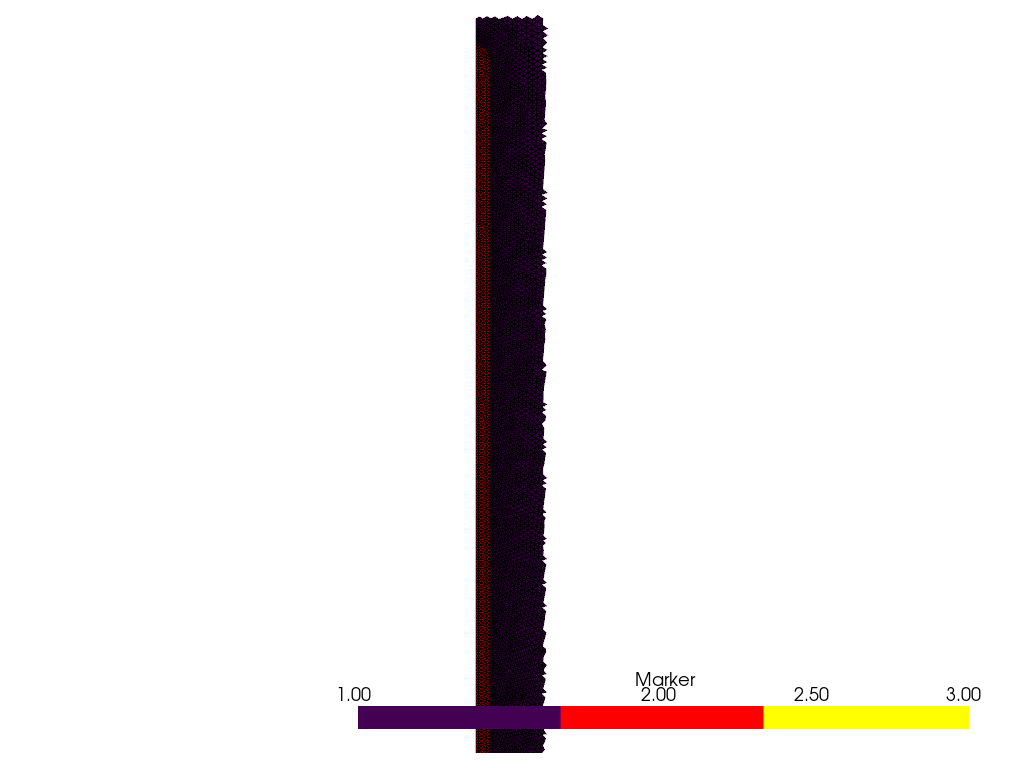

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


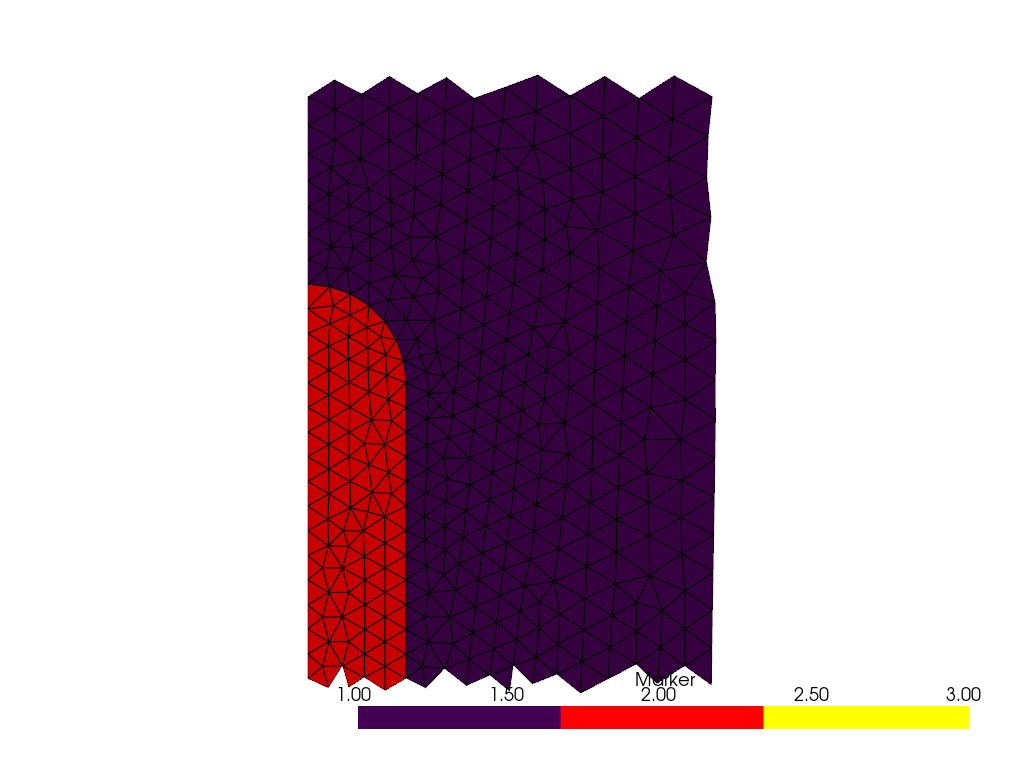

In [9]:
# Centros das células para fazer recortes
cell_centers = grid.cell_centers().points

# Função auxiliar para recortar e plotar uma região
def plot_zoom(x_min, x_max, y_min, y_max):
    ids = np.where(
        (cell_centers[:, 0] >= x_min) &
        (cell_centers[:, 0] <= x_max) &
        (cell_centers[:, 1] >= y_min) &
        (cell_centers[:, 1] <= y_max)
    )[0]

    zoom_grid = grid.extract_cells(ids)

    plotter = pyvista.Plotter()

    plotter.add_mesh(
        zoom_grid,
        scalars="Marker",
        show_edges=True,
        cmap=cmap_tags,
        clim=[1, 3],
        edge_color="black",
        show_scalar_bar=True
    )

    plotter.view_xy()
    plotter.show()

# Zoom no emissor inteiro
plot_zoom(
    x_min=0.0,
    x_max=0.30e-3,
    y_min=0.0,
    y_max=z_nozzle + 3*R
)

# Zoom na ponta circular do emissor
plot_zoom(
    x_min=0.0,
    x_max=0.25e-3,
    y_min=z_nozzle - 3*R,
    y_max=z_nozzle + 3*R
)